In [1]:
import pandas as pd
import utils as uti
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("../data/train_df.pkl")

In [3]:
import pickle
from pathlib import Path

file_path = Path("../data/models.pkl")

if file_path.exists():
    print('loading model file')
    with file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,V14,1951.546659,-0.099085,False
1,V4,1703.435651,-0.106422,False
2,V10,1617.13706,-0.102396,False
3,V3,1541.035483,-0.420856,True
4,V2,1478.19184,-0.530143,True


In [5]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [6]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [35]:
def objective(trial):
    params =     {
        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 300
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 20
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split", 5, 100
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 2, 50
        ),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "max_samples": trial.suggest_float(
            "max_samples", 0.5, 1.0
        ),
        "class_weight": trial.suggest_categorical(
            "class_weight",
            ["balanced", "balanced_subsample"]
        ),
        "random_state": 42,
        "n_jobs": 1,
    }
    
    
    # {
    #     "n_estimators": trial.suggest_int(
    #         "n_estimators", 50, 300
    #     ),

    #     # Include shallow trees; avoid allowing only very flexible models
    #     "max_depth": trial.suggest_categorical(
    #         "max_depth", [3, 4, 5, 6, 8, 12, None]
    #     ),

    #     "min_samples_split": trial.suggest_int(
    #         "min_samples_split", 5, 100
    #     ),

    #     "min_samples_leaf": trial.suggest_int(
    #         "min_samples_leaf", 2, 50
    #     ),

    #     "max_features": trial.suggest_categorical(
    #         "max_features", ["sqrt", "log2", 0.3, 0.5, None]
    #     ),

    #     "max_samples": trial.suggest_float(
    #         "max_samples", 0.5, 1.0
    #     ),

    #     "class_weight": trial.suggest_categorical(
    #         "class_weight",
    #         [None, "balanced", "balanced_subsample"]
    #     ),

    #     "random_state": 42,
    #     "n_jobs": 1,
    # }
        


    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    return scores.mean()


In [36]:
study = optuna.create_study(
    direction="maximize",
    study_name="random_forest_classifier"
)

study.optimize(objective, n_trials=15, show_progress_bar=True)

print("Best CV PR AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-09-09 03:06:41,683] A new study created in memory with name: random_forest_classifier


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-09 03:07:28,800] Trial 0 finished with value: 0.7239680574896693 and parameters: {'n_estimators': 210, 'max_depth': 3, 'min_samples_split': 87, 'min_samples_leaf': 21, 'max_features': 'log2', 'max_samples': 0.6571990764038621, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.7239680574896693.
[I 2026-09-09 03:09:15,237] Trial 1 finished with value: 0.7830283750540483 and parameters: {'n_estimators': 289, 'max_depth': 6, 'min_samples_split': 41, 'min_samples_leaf': 32, 'max_features': 'sqrt', 'max_samples': 0.8766358489841173, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.7830283750540483.
[I 2026-09-09 03:09:48,435] Trial 2 finished with value: 0.7385232356578003 and parameters: {'n_estimators': 115, 'max_depth': 3, 'min_samples_split': 19, 'min_samples_leaf': 14, 'max_features': 'sqrt', 'max_samples': 0.7138971048658498, 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.7830283750540483.
[I 2026-09-09 03:11:00,974] Trial 3

## optimization summary

In [37]:
import matplotlib.pyplot as plt

/tmp/ipykernel_1205874/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


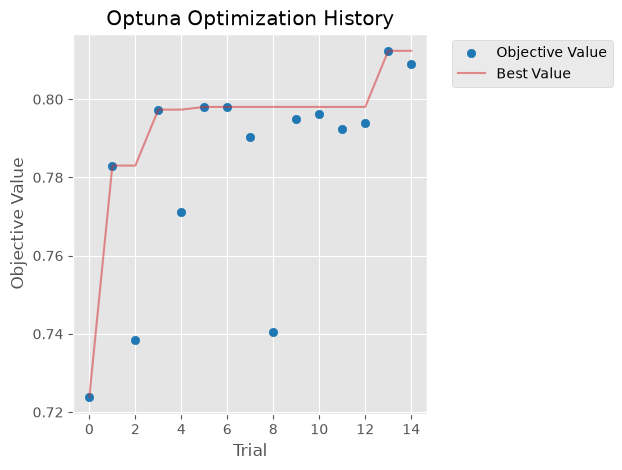

In [38]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

In [39]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_1205874/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


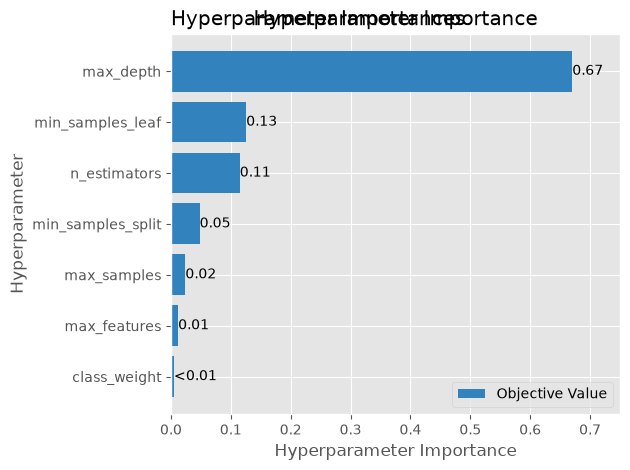

In [40]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1205874/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_1205874/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


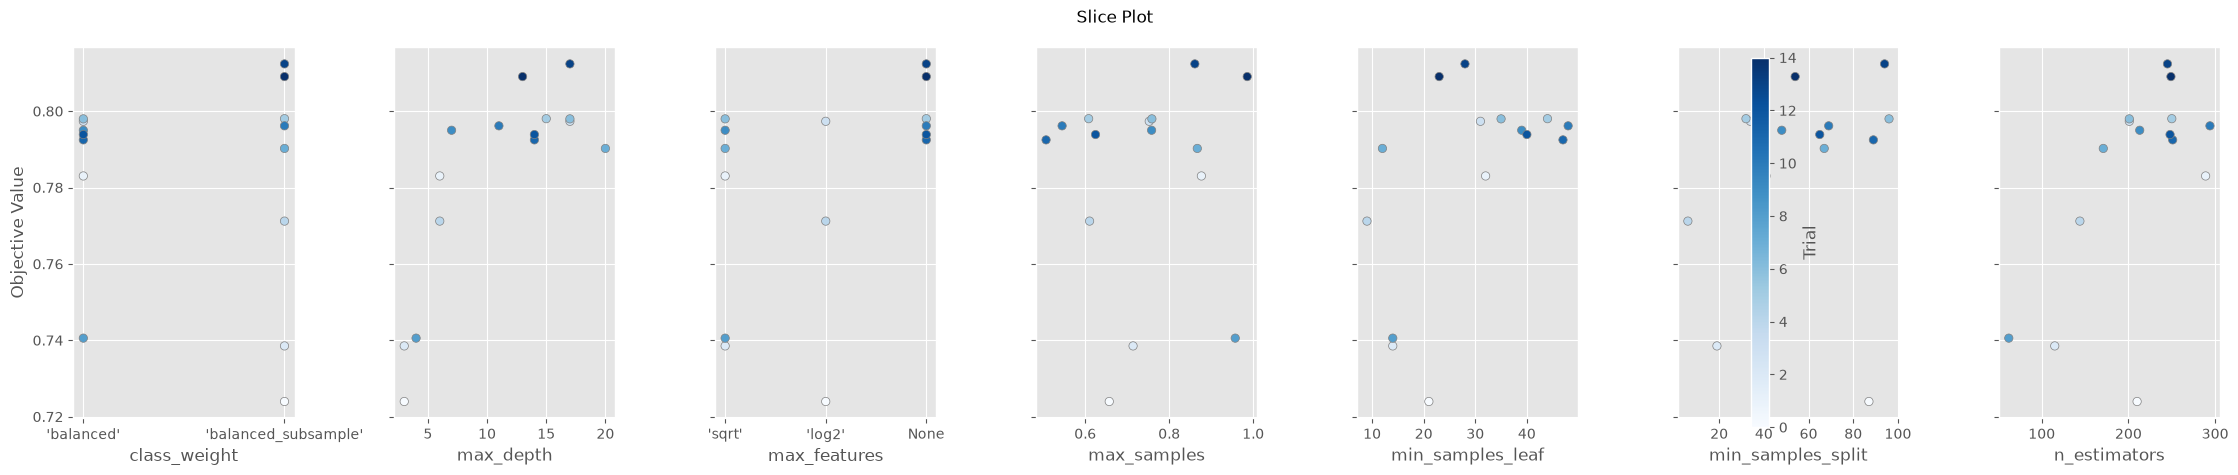

In [41]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1205874/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


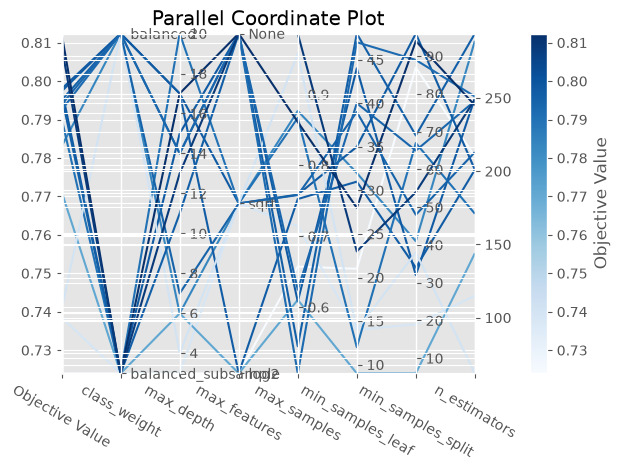

In [42]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1205874/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


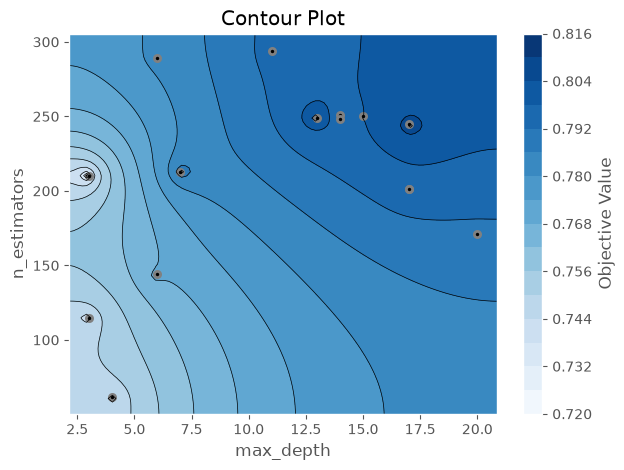

In [43]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [44]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

best_trials

,number,value,datetime_start,datetime_complete,duration,params_class_weight,params_max_depth,params_max_features,params_max_samples,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
13,13,0.812375,2026-09-09 03:50:19.612134,2026-09-09 04:04:55.799611,0 days 00:14:36.187477,balanced_subsample,17,NaN,0.861001,28,94,245,COMPLETE
14,14,0.809050,2026-09-09 04:04:55.801083,2026-09-09 04:21:20.596642,0 days 00:16:24.795559,balanced_subsample,13,NaN,0.985743,23,54,249,COMPLETE
5,5,0.798027,2026-09-09 03:11:52.816238,2026-09-09 03:22:14.179514,0 days 00:10:21.363276,balanced_subsample,15,NaN,0.608101,44,32,250,COMPLETE
6,6,0.797981,2026-09-09 03:22:14.181179,2026-09-09 03:23:39.864271,0 days 00:01:25.683092,balanced,17,sqrt,0.758681,35,96,201,COMPLETE
3,3,0.797339,2026-09-09 03:09:48.436177,2026-09-09 03:11:00.974085,0 days 00:01:12.537908,balanced,17,log2,0.752441,31,34,201,COMPLETE
10,10,0.796155,2026-09-09 03:27:17.666762,2026-09-09 03:38:06.327532,0 days 00:10:48.660770,balanced_subsample,11,NaN,0.544900,48,69,294,COMPLETE
9,9,0.794998,2026-09-09 03:26:01.407393,2026-09-09 03:27:17.665432,0 days 00:01:16.258039,balanced,7,sqrt,0.758016,39,48,213,COMPLETE
12,12,0.793877,2026-09-09 03:43:41.027967,2026-09-09 03:50:19.610855,0 days 00:06:38.582888,balanced,14,NaN,0.624483,40,65,248,COMPLETE
11,11,0.792478,2026-09-09 03:38:06.328920,2026-09-09 03:43:41.026676,0 days 00:05:34.697756,balanced,14,NaN,0.506700,47,89,251,COMPLETE
7,7,0.790234,2026-09-09 03:23:39.865379,2026-09-09 03:25:43.733766,0 days 00:02:03.868387,balanced_subsample,20,sqrt,0.866863,12,67,171,COMPLETE


# fit best model

In [45]:
best_model = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",245
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",17
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",94
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",28
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanc

In [46]:
models['rf'] = best_model

## partial dependence plots

In [47]:
# from sklearn.inspection import PartialDependenceDisplay

# PartialDependenceDisplay.from_estimator(
#     best_model,
#     X,
#     features=walds['var'].tolist()
# )

# plt.show()

# save model

In [48]:
with open("../data/models.pkl", "wb") as file:
    pickle.dump(models, file)